In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn import tree


import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pathlib import Path


# Project Objectives
Provider Fraud is one of the biggest problems facing Medicare. According to the government, the total Medicare spending increased exponentially due to frauds in Medicare claims. Healthcare fraud is an organized crime which involves peers of providers, physicians, beneficiaries acting together to make fraud claims.

Rigorous analysis of Medicare data has yielded many physicians who indulge in fraud. They adopt ways in which an ambiguous diagnosis code is used to adopt costliest procedures and drugs. Insurance companies are the most vulnerable institutions impacted due to these bad practices. Due to this reason, insurance companies increased their insurance premiums and as result healthcare is becoming costly matter day by day.

Healthcare fraud and abuse take many forms. Some of the most common types of frauds by providers are:

a) Billing for services that were not provided.

b) Duplicate submission of a claim for the same service.

c) Misrepresenting the service provided.

d) Charging for a more complex or expensive service than was actually provided.

e) Billing for a covered service when the service actually provided was not covered.

# Problem Statement: Predict the potentially fraudulent providers
The goal of this project is to " predict the potentially fraudulent providers " based on the claims filed by them.along with this, we will also discover important variables helpful in detecting the behaviour of potentially fraud providers. further, we will study fraudulent patterns in the provider's claims to understand the future behaviour of providers.

# Introduction to the Dataset
For the purpose of this project, we are considering Inpatient claims, Outpatient claims and Beneficiary details of each provider. Lets s see their details :

A) Inpatient Data

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admitted diagnosis code.

B) Outpatient Data

This data provides details about the claims filed for those patients who visit hospitals and not admitted in it.

C) Beneficiary Details Data (unique BeneID)

This data contains beneficiary KYC details like health conditions, region they belong to etc.

The "Split" Architecture: * Use Notebooks for EDA: Keep your .ipynb files strictly for Exploratory Data Analysis, visualizing the 9% fraud imbalance, and showing your thought process.

Use .py files for Logic: Once you figure out how to clean the claims data or engineer new features, move that code out of the notebook and into dedicated Python scripts (e.g., src/features/claims_preprocessing.py). Import these scripts into your notebook. This shows you know how to write modular, testable code.

# 1. Load Data/EDA

In [2]:
data_folder = Path('data')
train_dataframes = {}
test_dataframes = {}
for file in data_folder.glob('*.csv'):
    file_name = file.stem
    if file_name.lower().startswith("train"):
        train_dataframes[file_name] = pd.read_csv(file)
        print(f"Loaded into TRAIN: {file_name}")
            
    elif file_name.lower().startswith("test"):
        test_dataframes[file_name] = pd.read_csv(file)
        print(f"Loaded into TEST: {file_name}")
            
    else:
        print(f"Ignored: {file_name} (Did not match Train or Test prefix)")

Loaded into TRAIN: Train_Inpatientdata-1542865627584
Loaded into TRAIN: Train_Outpatientdata-1542865627584
Loaded into TEST: Test_Inpatientdata-1542969243754
Loaded into TEST: Test_Beneficiarydata-1542969243754
Loaded into TRAIN: Train-1542865627584
Loaded into TRAIN: Train_Beneficiarydata-1542865627584
Loaded into TEST: Test_Outpatientdata-1542969243754
Loaded into TEST: Test-1542969243754


A) Inpatient Data

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admit d diagnosis code.

In [3]:
train_labels = train_dataframes['Train-1542865627584']
ben = train_dataframes['Train_Beneficiarydata-1542865627584']
inpatient =  train_dataframes['Train_Inpatientdata-1542865627584']
outpatient = train_dataframes['Train_Outpatientdata-1542865627584']

# fraud rate
fraud_rate = train_labels['PotentialFraud'].value_counts(normalize=True)
print(f"\nFraud rate: {fraud_rate.get('Yes', 0):.1%}")


Fraud rate: 9.4%


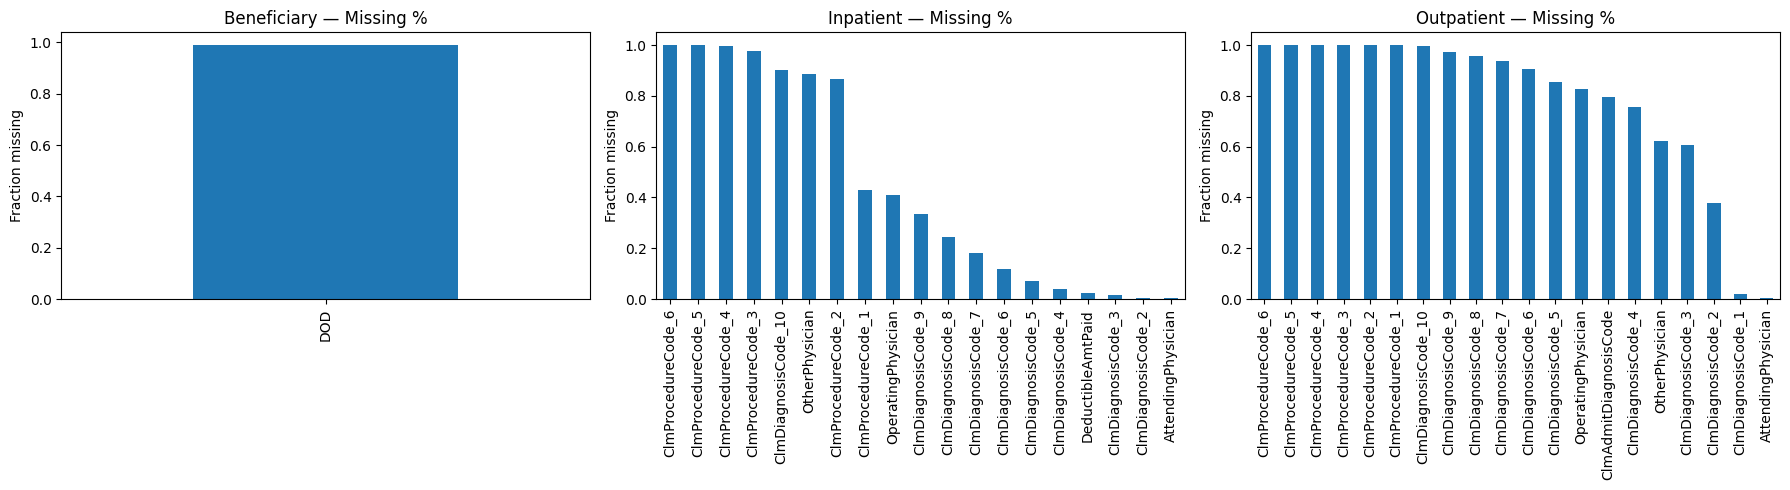

In [11]:
# Missingness heatmap for all columns in beneficiary, inpatient, and outpatient
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, [('Beneficiary', ben),
                                   ('Inpatient', inpatient),
                                   ('Outpatient', outpatient)]):
    missing = df.isnull().mean().sort_values(ascending=False)
    missing[missing > 0].plot.bar(ax=ax)
    ax.set_title(f'{name} — Missing %')
    ax.set_ylabel('Fraction missing')
plt.tight_layout()
plt.savefig('missingness_overview.png', dpi=150)

In [ ]:
# ben.IPAnnualReimbursementAmt.plot()
# ben.info()

# 2. Data Cleaning 

### RenalDiseaseIndicator: 0 and Y as values; change to inttype 0 and 1
### Chronic Disease columns: 2 = FALSE; 1 = TRUE

In [12]:
# RenalDiseaseIndicator: 0 and Y as values; change to inttype 0 and 1
ben['RenalDiseaseIndicator']= np.where(ben['RenalDiseaseIndicator'] == 'Y', 1, 0)

# Add RenalDiseaseIndicator
chronic_cols = [c for c in ben.columns if c.startswith('Chronic')]
chronic_cols.append('RenalDiseaseIndicator')

# Count chronic conditions per beneficiary 
# Values for ChronicCond***: 2 = FALSE; 1 = TRUE
ben['chronic_count'] = ben[chronic_cols].apply(lambda row: (row==1).sum(), axis=1)  # Get the sum of chronic conditions per individual



In [13]:
# Change to datetime
date_cols_ip = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']
date_cols_op = ['ClaimStartDt', 'ClaimEndDt']
date_cols_ben = ['DOB', 'DOD']

# inpatient
for col in date_cols_ip:
    inpatient[col] = pd.to_datetime(inpatient[col])

# outpatient
for col in date_cols_op:
    outpatient[col] = pd.to_datetime(outpatient[col])

# beneficiary
for col in date_cols_ben:
    ben[col] = pd.to_datetime(ben[col])

## 3. New columns/features
- **Inpatient:**  num_diag_codes, num_proc_codes, claim_duration_days, age, los_days
- **Outpatient:** num_diag_codes, num_proc_codes, claim_duration_days, age
- **benificiary**: is_deceased

**NOTE**: num_proc_codes is much sparser in outpatient dataset

In [14]:
# Derived Time - inpatient
inpatient['claim_duration_days'] =  (inpatient['ClaimEndDt'] - inpatient['ClaimStartDt']).dt.days
inpatient['los_days'] =             (inpatient['DischargeDt'] - inpatient['AdmissionDt']).dt.days

# Derived Time - outpatient
outpatient['claim_duration_days'] = (outpatient['ClaimEndDt'] - outpatient['ClaimStartDt']).dt.days

# Is the patient deceased? 
ben['is_deceased'] = ben['DOD'].notna().astype(int)   # If NA-->0; Else 1

In [15]:
# Inpatient Number of diagnosis/procedure codes per claim - Count when not NA
diag_cols = [c for c in inpatient.columns if c.startswith('ClmDiagnosisCode')]
proc_cols = [c for c in inpatient.columns if c.startswith('ClmProcedureCode')]

inpatient['num_diag_codes'] = inpatient[diag_cols].notna().sum(axis=1)
inpatient['num_proc_codes'] = inpatient[proc_cols].notna().sum(axis=1)

# Outpatient Number of diagnosis/procedure codes per claim - Count when not NA
op_diag_cols = [c for c in outpatient.columns if c.startswith('ClmDiagnosisCode')]
op_proc_cols = [c for c in outpatient.columns if c.startswith('ClmProcedureCode')]

outpatient['num_diag_codes'] = outpatient[op_diag_cols].notna().sum(axis=1)
outpatient['num_proc_codes'] = outpatient[op_proc_cols].notna().sum(axis=1)

# Patient Age (Inpatient & Outpatient)
inpatient =   inpatient.merge(ben[['BeneID', 'DOB']], on='BeneID', how='left')
inpatient['patient_age'] = (
    (inpatient['ClaimStartDt'] - inpatient['DOB']).dt.days / 365.25
).round(1)

outpatient = outpatient.merge(ben[['BeneID', 'DOB']], on='BeneID', how='left')
outpatient['patient_age'] = (
    (outpatient['ClaimStartDt'] - outpatient['DOB']).dt.days / 365.25
).round(1)
                            

In [ ]:
# outpatient[outpatient['num_proc_codes'] >0].count()
# outpatient.num_proc_codes.value_counts()

## Combine inpatient + outpatient

In [5]:
print(outpatient.BeneID.nunique())
# outpatient.columns
inpatient.columns

133980


Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6'],
      dtype='str')

In [6]:
print(inpatient.OtherPhysician.isna().sum())
print(inpatient.OperatingPhysician.isna().sum())
print(outpatient.OtherPhysician.isna().sum())
print(outpatient.OperatingPhysician.isna().sum())

35784
16644
322691
427120


### Note: Since I summed the outpatient procedure codes and the ip and op dfs are concatenanted, will it affect the 

In [16]:
# ── Tag claim type, then stack ──
inpatient['claim_type']  = 'inpatient'
outpatient['claim_type'] = 'outpatient'

# Align columns — outpatient won't have LOS
shared_cols = [
    'BeneID', 'ClaimID', 'patient_age',
    'Provider', 'InscClaimAmtReimbursed','DeductibleAmtPaid', 'claim_duration_days', 
    'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
    'num_diag_codes', 'num_proc_codes', 'claim_type'
]

all_claims = pd.concat([
    inpatient[shared_cols + ['los_days']],
    outpatient[shared_cols].assign(los_days=np.nan)], ignore_index=True)

# ── Merge desired benificiary columns including chronic condition burden --
bene_features = ben[['BeneID', 'chronic_count', 'is_deceased', 
                              'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
                              'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']]
all_claims = all_claims.merge(bene_features, on='BeneID', how='left')

# 3. Provider-level aggregation
- Because the problem statement is to **predict the potentially fraudulent providers based on the claims filed by them**, and we aggregate at the provider level, will  

- mean_reimbursement — The most obvious signal. Fraudulent providers tend to bill for higher-cost services (upcoding). A provider whose average claim reimbursement is 2-3× the population mean is doing something worth investigating.
- claims_per_patient — Churning. Fraud rings cycle the same patients through repeated visits or fabricate claims entirely. A legitimate provider might see a patient 3-4 times a year; a fraudulent one might bill 20+ encounters per patient.
- mean_los — Length of stay manipulation. Keeping patients admitted longer inflates inpatient reimbursement. Conversely, suspiciously short stays with high-cost procedure codes suggest the admission was unnecessary.
- mean_diag_codes — Diagnosis stacking. Listing more diagnosis codes per claim increases reimbursement under DRG-based payment. A provider consistently maxing out diagnosis slots is a red flag.
- pct_deceased_patients — Billing for dead people. This is one of the most well-documented Medicare fraud patterns. A provider whose patient panel has an unusually high mortality rate may be submitting claims for patients who are already deceased.
- pct_inpatient — Inpatient claims reimburse much higher than outpatient. A provider with an unusually high inpatient mix might be admitting patients who should be treated outpatient.
- cv_reimbursement — Coefficient of variation captures billing pattern consistency. Legitimate providers tend to have a natural spread based on their specialty. Fraudulent providers often show either suspiciously uniform billing (same amount over and over, suggesting fabricated claims) or extreme variance (mixing legitimate claims with inflated ones).
unique_patients — Panel size context. A solo practitioner seeing 5,000 unique patients a year is physically impossible. It also serves as a denominator check for the ratio features.

In [8]:
all_claims

NameError: name 'all_claims' is not defined

In [17]:
provider_features = all_claims.groupby('Provider').agg(
    total_claims=('ClaimID', 'nunique'),
    unique_patients=('BeneID', 'nunique'),
    unique_physicians=('AttendingPhysician', 'nunique'),

    # Financial signals
    mean_reimbursement=('InscClaimAmtReimbursed', 'mean'),
    median_reimbursement=('InscClaimAmtReimbursed', 'median'),
    std_reimbursement=('InscClaimAmtReimbursed', 'std'),
    total_reimbursement=('InscClaimAmtReimbursed', 'sum'),
    max_reimbursement=('InscClaimAmtReimbursed', 'max'),
    mean_deductible=('DeductibleAmtPaid', 'mean'),

    # Duration signals
    mean_claim_duration=('claim_duration_days', 'mean'),
    mean_los=('los_days', 'mean'),

    # Complexity signals
    mean_diag_codes=('num_diag_codes', 'mean'),
    max_diag_codes=('num_diag_codes', 'max'),
    mean_proc_codes=('num_proc_codes', 'mean'),

    # Patient risk signals
    mean_patient_age=('patient_age', 'mean'),
    mean_chronic_count=('chronic_count', 'mean'),
    pct_deceased_patients=('is_deceased', 'mean'),

    # Mix signals
    pct_inpatient=('claim_type', lambda x: (x == 'inpatient').mean()),  # 1 if inpatient and 0 if outpatient

    # Annual reimbursement of their patient panel
    mean_ip_annual_reimb=('IPAnnualReimbursementAmt', 'mean'),
    mean_op_annual_reimb=('OPAnnualReimbursementAmt', 'mean'),
    mean_ip_annual_deduct=('IPAnnualDeductibleAmt', 'mean'),
    mean_op_annual_deduct=('OPAnnualDeductibleAmt', 'mean'),
).reset_index()

# ── Derived ratios ──
provider_features['claims_per_patient'] = (
    provider_features['total_claims'] / provider_features['unique_patients']
)
provider_features['reimbursement_per_patient'] = (
    provider_features['total_reimbursement'] / provider_features['unique_patients']
)
# Coefficient of Variation - captures billing pattern consistency
provider_features['cv_reimbursement'] = (
    provider_features['std_reimbursement'] / provider_features['mean_reimbursement']
).fillna(0)

# ── Merge with labels ── Inner join because we only have providers in the training labels
train_labels['PotentialFraud'] = train_labels['PotentialFraud'].map({'Yes': 1, 'No': 0})
modeling_df = provider_features.merge(train_labels, on='Provider', how='inner')

print(f"Final modeling table: {modeling_df.shape}")
print(f"Fraud rate: {modeling_df['PotentialFraud'].mean():.1%}")

Final modeling table: (5410, 27)
Fraud rate: 9.4%



Correlation with fraud label:
pct_deceased_patients    0.008775
mean_los                 0.083799
claims_per_patient       0.093482
cv_reimbursement         0.164133
mean_diag_codes          0.189909
mean_reimbursement       0.193803
pct_inpatient            0.205683
unique_patients          0.393531


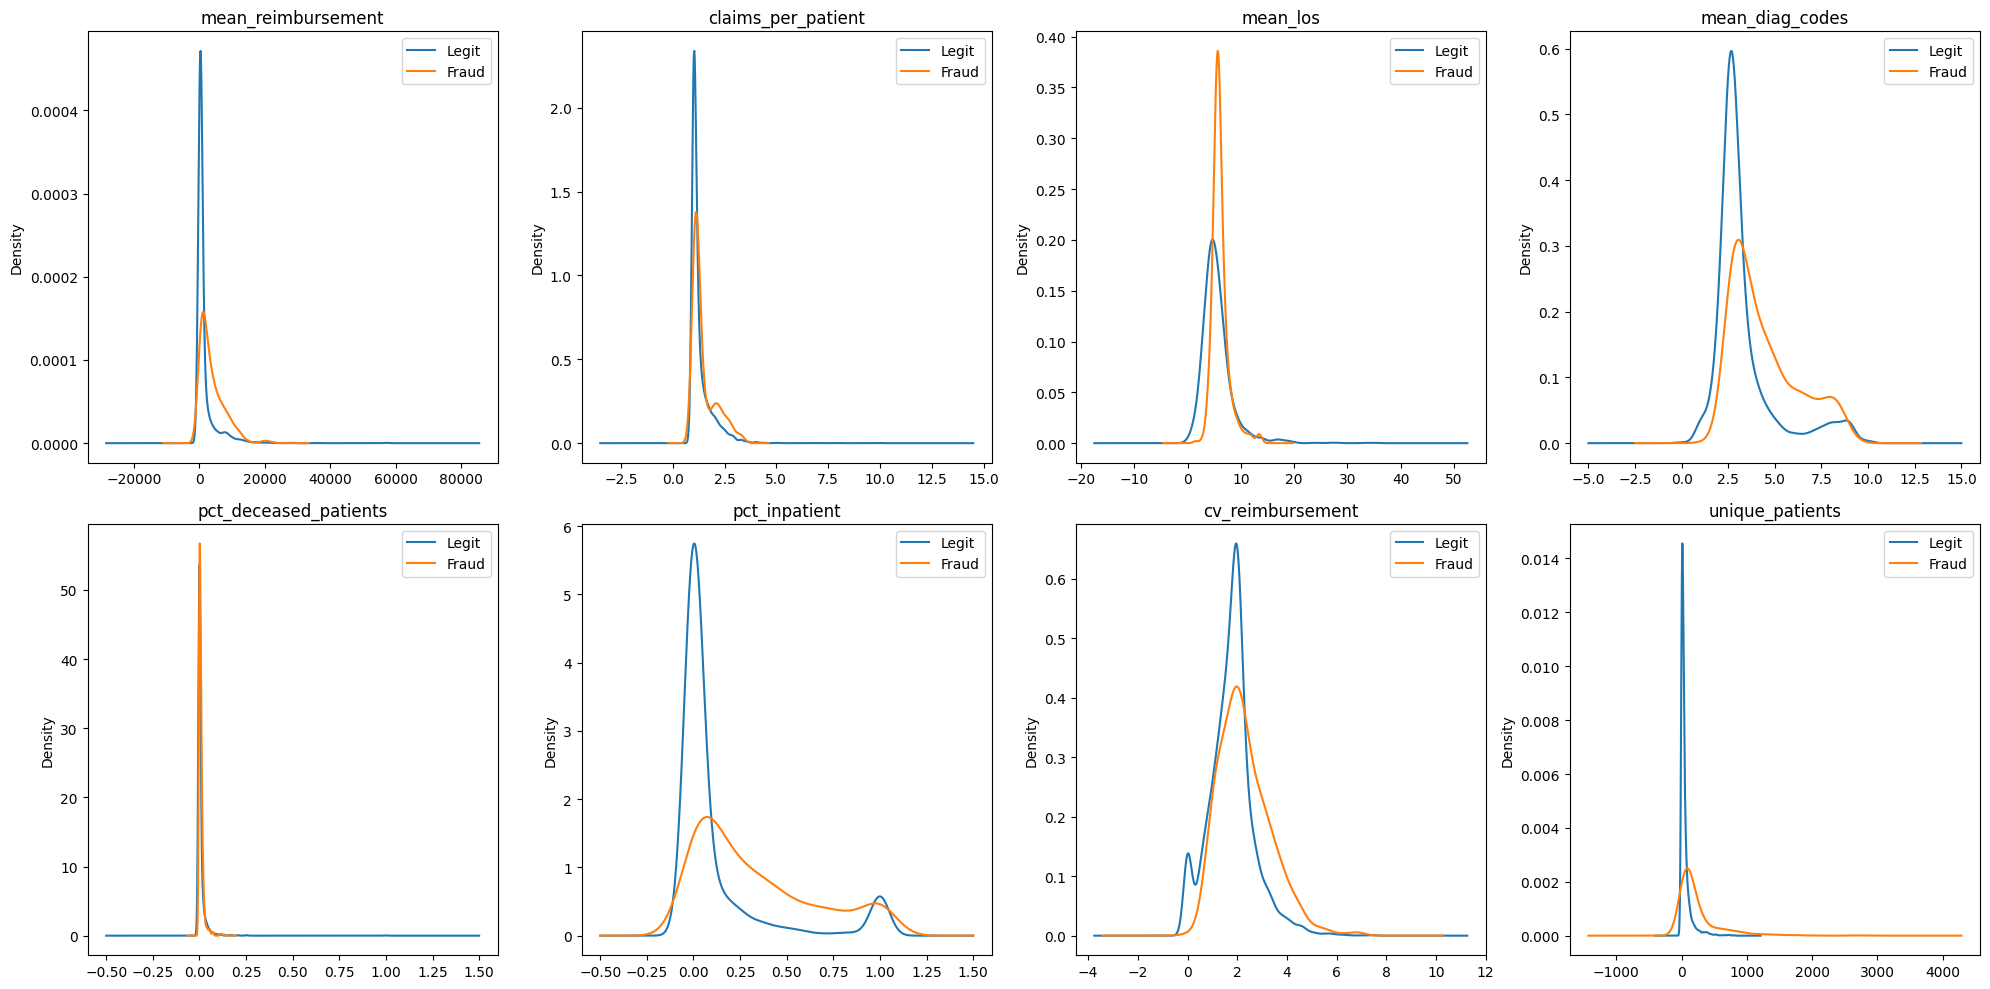

In [19]:
fraud_flag = modeling_df['PotentialFraud'] == 1

key_features = [
    'mean_reimbursement', 'claims_per_patient', 'mean_los',
    'mean_diag_codes', 'pct_deceased_patients', 'pct_inpatient',
    'cv_reimbursement', 'unique_patients'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, feat in zip(axes.ravel(), key_features):
    modeling_df.groupby('PotentialFraud')[feat].plot.kde(ax=ax, legend=True)
    ax.set_title(feat)
    ax.legend(['Legit', 'Fraud'])
plt.tight_layout()
plt.savefig('fraud_signal_distributions.png', dpi=150)

# ── Correlation heatmap of top features vs target ──
corr = modeling_df[key_features + ['PotentialFraud']].corr()['PotentialFraud'] \
    .drop('PotentialFraud').sort_values()
print("\nCorrelation with fraud label:")
print(corr.to_string())

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

# Smote (Imbalanced Learning)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 4. Modeling
- Stratified K-fold to preserve fraud ratio (class imbalance)
- Use AUC to select best model during training and F1 score to evaluate final model

### Modeling Strategies to handle Class Imbalance
1. Built-in Class weights
2. SMOTE
3. RandomForest with class weights
4. XGBoost with scale_pos_weight (num_legit/num_fraud) 

In [24]:
df = modeling_df.copy()
drop_cols = ['Provider', 'PotentialFraud']
X = df.drop(columns=drop_cols).fillna(0)
y = df['PotentialFraud']

# Stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [27]:
y.value_counts()

PotentialFraud
0    4904
1     506
Name: count, dtype: int64

In [29]:
# Method 1: Built-in Class weights
lr_weighted = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Method 2: SMOTE oversampling
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=1)),
    ('clf', LogisticRegression(max_iter=1000))
])
# Method 3: RandomForest with class weights
rf_weighted = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=1)

# Method 4: XGBoost with 'scale_pos_weight' = (num_legit/num_fraud) 
fraud_ratio = (y==0).sum()/(y==1).sum()
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=fraud_ratio,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs= -1
)

In [35]:
# Evaluate 
models = {
    'LR_weighted': lr_weighted,
    'LR_SMOTE': smote_pipeline,
    'XGB_weighted': xgb_model,
    'RF_weighted': rf_weighted
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    results[name] = scores
    print(f"{name}: AUC = {scores.mean():.4f} ± {scores.std():.4f}")

/Users/evan/Documents/Personal/Coding_Projects/Kaggle/Healthcare_fraud/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/evan/Documents/Personal/Coding_Projects/Kaggle/Healthcare_fraud/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000)

LR_weighted: AUC = 0.9362 ± 0.0127
LR_SMOTE: AUC = 0.9430 ± 0.0116
XGB_weighted: AUC = 0.9391 ± 0.0124
RF_weighted: AUC = 0.9347 ± 0.0137


Unlike GridSearch, RandomizedSearchCV evaluates a fixed number of randomly sampled parameter combinations from defined numbers/ranges

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 1.5, 2.0],
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=fraud_ratio,
        eval_metric='auc',
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=50,  # parameter settings sampled
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs= -1, 
    verbose=1
)
search.fit(X, y)
print(f"Best AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")
best_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best AUC: 0.9422
Best params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}


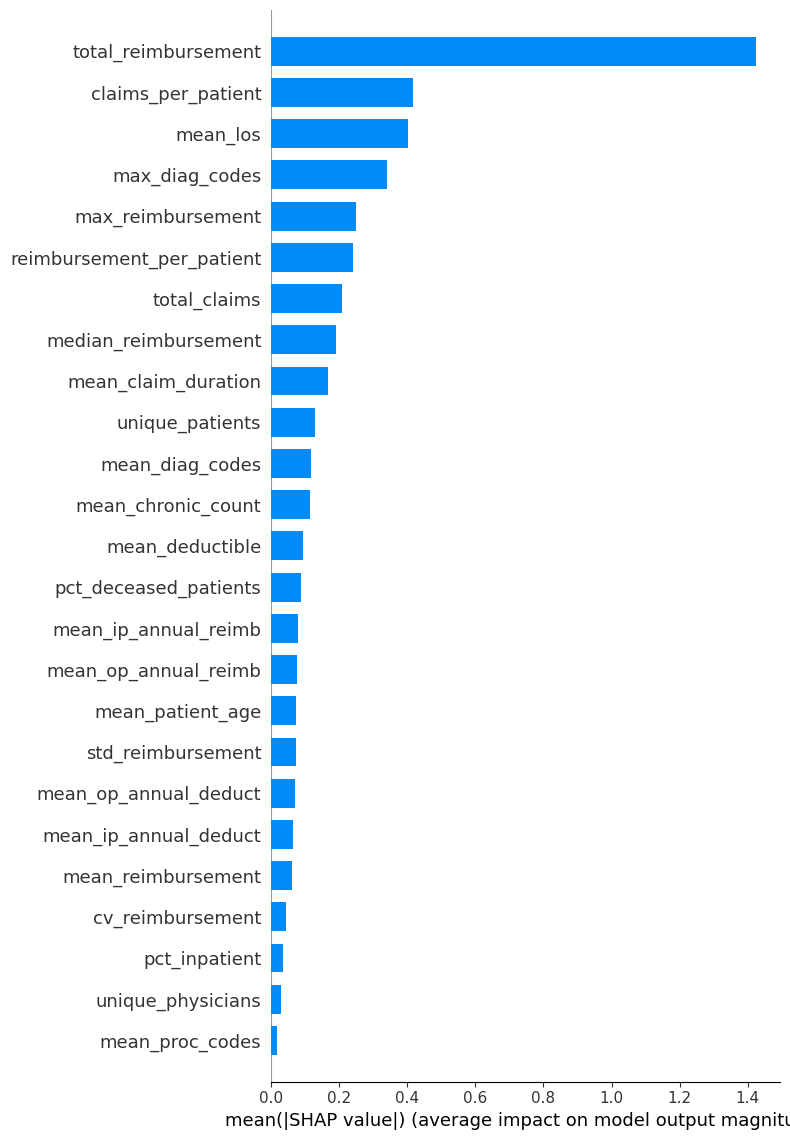

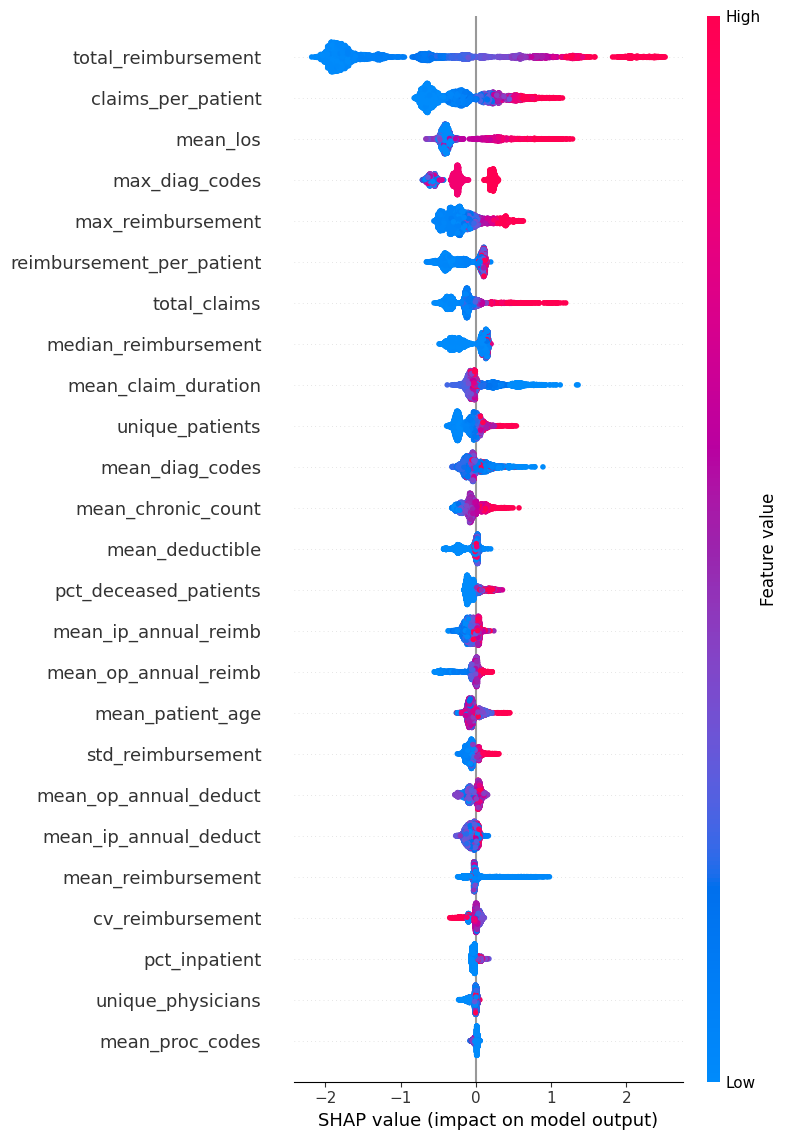

<Figure size 640x480 with 0 Axes>

In [41]:
import shap

best_model.fit(X, y)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

# ── Global feature importance ──
shap.summary_plot(shap_values, X, plot_type='bar', max_display=30)
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')

# ── Beeswarm — direction of effect ──
shap.summary_plot(shap_values, X, max_display=30)
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')

- total_reimbursement (Clean/Intuitive) is the strongest predictor. The red dots are pushed far to the right — high total billing strongly predicts fraud. The blue dots (low billing) cluster slightly left of zero
- claims_per_patient(Clean/Intuitive) - red dots right, blue dots left. Providers churning more claims per patient get flagged. This is the classic billing mill signature.
- mean_los - red tail extends very far right. A small number of providers with extremely high average length of stay are getting massive SHAP push toward fraud. That long red tail suggests a few egregious outliers are driving this feature's importance.
- max_diag_codes has a tight, almost binary split — red dots right, blue dots left, with little spread. This means the feature is acting almost like a threshold: either you're maxing out diagnosis code slots or you're not, and maxing them out points toward fraud.
- total_claims is interesting — notice how the red dots extend far right but the blue cluster is tight. High volume providers get flagged, but low volume doesn't particularly exonerate you. It's a one-directional signal.

In [47]:
def explain_provider(provider_idx, X, shap_values, modeling_df):
    """Generate a human-readable fraud explanation for a single provider."""
    provider_id = modeling_df.iloc[provider_idx]['Provider']
    # predict_proba returns a 2D array of shape (1, 2) — probabilities for class 0 (legit) and class 1 (fraud). 
    # [0][1] grabs the first row, second column, which is the fraud probability
    fraud_prob = best_model.predict_proba(X.iloc[[provider_idx]])[0][1]

    print(f"Provider: {provider_id}")
    print(f"Fraud probability: {fraud_prob:.1%}")
    print(f"{'─' * 50}")

    # Top 5 risk drivers for 1 single provider
    sv = pd.Series(shap_values[provider_idx], index=X.columns)
    top_drivers = sv.abs().nlargest(5)

    # Get the singular provider's feature value compared to the mean 
    for feat in top_drivers.index:
        direction = " higher RISK" if sv[feat] > 0 else "lower risk"
        actual_val = X.iloc[provider_idx][feat]
        pop_mean = X[feat].mean()
        print(f"  {feat}: {actual_val:.2f} (pop avg: {pop_mean:.2f}) → {direction}")

# ── Example: explain the highest-risk provider ──
fraud_probs = best_model.predict_proba(X)[:, 1]     # [:, 1] returns all rows for SECOND column (which contains the probability of fraud)
riskiest = fraud_probs.argmax()
explain_provider(riskiest, X, shap_values, modeling_df)

Provider: PRV52340
Fraud probability: 99.1%
──────────────────────────────────────────────────
  total_reimbursement: 2540130.00 (pop avg: 102873.04) →  higher RISK
  total_claims: 1743.00 (pop avg: 103.18) →  higher RISK
  claims_per_patient: 2.52 (pop avg: 1.33) →  higher RISK
  max_reimbursement: 57000.00 (pop avg: 13014.91) →  higher RISK
  max_diag_codes: 10.00 (pop avg: 8.15) →  higher RISK


In [ ]:
best_model.predict_proba(X[0][1]

In [46]:
fraud_probs

array([0.3389571 , 0.96904504, 0.04884242, ..., 0.02078137, 0.01435312,
       0.10453734], shape=(5410,), dtype=float32)

In [45]:
riskiest

np.int64(1071)

ROC-AUC: 0.9589
PR-AUC:  0.7389

At top-15% threshold (0.636):
              precision    recall  f1-score   support

       Legit       0.98      0.92      0.95       981
       Fraud       0.51      0.82      0.63       101

    accuracy                           0.91      1082
   macro avg       0.74      0.87      0.79      1082
weighted avg       0.94      0.91      0.92      1082



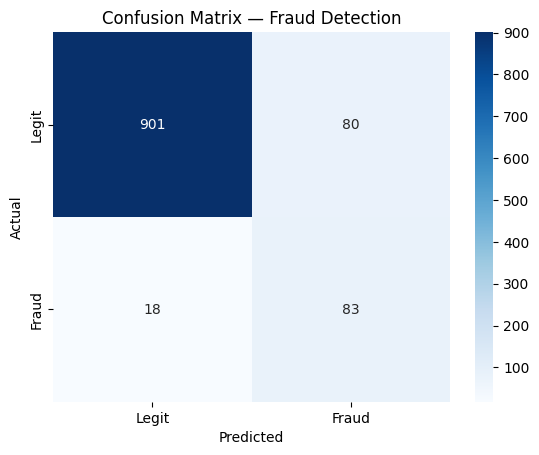

In [50]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_val)[:, 1]

# ── ROC-AUC ──
roc_auc = roc_auc_score(y_val, y_proba)

# ── Precision-Recall AUC (the metric that matters) ──
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

# ── At a practical threshold (e.g., top 15% flagged for review) ──
threshold = np.percentile(y_proba, 85)    # Quantifies the CUTOFF for top 15% highest probability for fraud
y_pred = (y_proba >= threshold).astype(int)
print(f"\nAt top-15% threshold ({threshold:.3f}):")
print(classification_report(y_val, y_pred, target_names=['Legit', 'Fraud']))

# ── Confusion matrix ──
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Fraud Detection')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')